4.1. Загрузка The number of crimes in Russia 2008-2023.csv

In [2]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path("The number of crimes in Russia 2008-2023.csv")
df = pd.read_csv(DATA_PATH)
print(df.shape)
print(df.columns.tolist())
df.head()

(12384, 5)
['Type of crime', 'Region', 'Year', 'The number of crimes', 'The number of crimes (cases per 100.000 population)']


,Type of crime,Region,Year,The number of crimes,The number of crimes (cases per 100.000 population)
0,Murder,Russian Federation,2008,19740.0,13.8
1,Murder,Belgorod Oblast,2008,98.0,6.4
2,Murder,Bryansk Oblast,2008,155.0,11.9
3,Murder,Vladimir Oblast,2008,176.0,12.0
4,Murder,Voronezh Oblast,2008,177.0,7.5


Вывод по блоку: Успешная загрузка

5.1. Структура и память

In [3]:
import io
buf = io.StringIO()
df.info(buf=buf, memory_usage="deep")
print(buf.getvalue())

<class 'pandas.DataFrame'>
RangeIndex: 12384 entries, 0 to 12383
Data columns (total 5 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Type of crime                                        12384 non-null  str    
 1   Region                                               12384 non-null  str    
 2   Year                                                 12384 non-null  int64  
 3   The number of crimes                                 12108 non-null  float64
 4   The number of crimes (cases per 100.000 population)  12092 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 875.4 KB



5.2. Пропуски, дубликаты и уникальные значения

In [4]:
print("Пропуски по столбцам:")
print(df.isna().sum())
print("Полных дубликатов:", df.duplicated().sum())
print("Число уникальных значений:")
print(df.nunique())

Пропуски по столбцам:
Type of crime                                            0
Region                                                   0
Year                                                     0
The number of crimes                                   276
The number of crimes (cases per 100.000 population)    292
dtype: int64
Полных дубликатов: 0
Число уникальных значений:
Type of crime                                             9
Region                                                   86
Year                                                     16
The number of crimes                                   3007
The number of crimes (cases per 100.000 population)    2568
dtype: int64


5.3. Проверка соответствия категорий (Типы преступлений и Регионы)

In [5]:
type_map = (
 df[["Region", "Type of crime"]]
 .drop_duplicates()
 .sort_values("Region")
)
print(type_map.to_string(index=False))

                               Region                             Type of crime
                           Altai Krai                                    Murder
                           Altai Krai                   Intentional Bodily Harm
                           Altai Krai                                      Rape
                           Altai Krai                                     Theft
                           Altai Krai                  Robbery without violence
                           Altai Krai                     Robbery with violence
                           Altai Krai                                 Extortion
                           Altai Krai                               Hooliganism
                           Altai Krai Crimes in the Sphere of Economic Activity
                       Altai Republic                                    Murder
                       Altai Republic                   Intentional Bodily Harm
                       Altai Republic   

5.4. Описательная статистика

In [6]:
cols = [
    "The number of crimes",
    "The number of crimes (cases per 100.000 population)"
]

print(df[cols].describe().round(2).T)

                                                      count     mean  \
The number of crimes                                12108.0  3082.85   
The number of crimes (cases per 100.000 populat...  12092.0    89.65   

                                                         std  min   25%  \
The number of crimes                                34485.28  0.0  37.0   
The number of crimes (cases per 100.000 populat...    210.64  0.0   3.3   

                                                      50%    75%        max  
The number of crimes                                130.5  655.0  1326342.0  
The number of crimes (cases per 100.000 populat...   10.0   50.7     1853.9  


1 Датасет содержит информацию о 9 типах преступлений по регионам РФ за 16 лет.

2 Пропуски присутствуют только в категории «Преступления в сфере экономической деятельности» (данные отсутствуют до 2010 года) и в регионах Крым/Севастополь за периоды до их включения в состав РФ. Дубликатов нет.

6.1. Оптимизация типов данных

In [7]:
before = df.memory_usage(deep=True).sum()
clean_df = df.copy()
clean_df["Type of crime"] = clean_df["Type of crime"].astype("category")
clean_df["Region"] = clean_df["Region"].astype("category")
clean_df["Year"] = clean_df["Year"].astype("int16")

after = clean_df.memory_usage(deep=True).sum()
print(f"До: {before / 1024**2:.2f} MiB")
print(f"После: {after / 1024**2:.2f} MiB")
print(f"Снижение: {(1 - after / before) * 100:.1f}%")

До: 0.85 MiB
После: 0.24 MiB
Снижение: 72.1%


6.2. Создание вычисляемых признаков

In [8]:
clean_df["is_federal_level"] = (
    clean_df["Region"] == "Russian Federation"
)


print(clean_df[
    ["Type of crime", "Region", "Year", "The number of crimes", "is_federal_level"]
].head())

  Type of crime              Region  Year  The number of crimes  \
0        Murder  Russian Federation  2008               19740.0   
1        Murder     Belgorod Oblast  2008                  98.0   
2        Murder      Bryansk Oblast  2008                 155.0   
3        Murder     Vladimir Oblast  2008                 176.0   
4        Murder     Voronezh Oblast  2008                 177.0   

   is_federal_level  
0              True  
1             False  
2             False  
3             False  
4             False  


1 Применение типов данных category и int16 позволило значительно сократить объем занимаемой памяти.

2 Создан бинарный признак для фильтрации особо тяжких преступлений, что упрощает дальнейший анализ.

7.1. Распределение наблюдений по типам

In [9]:
type_stats = (
    clean_df["Type of crime"]
    .value_counts()
    .to_frame("n")
    .assign(share_pct=lambda x: x["n"] / len(clean_df) * 100)
)
print(type_stats.round(2))

                                              n  share_pct
Type of crime                                             
Crimes in the Sphere of Economic Activity  1376      11.11
Extortion                                  1376      11.11
Hooliganism                                1376      11.11
Intentional Bodily Harm                    1376      11.11
Murder                                     1376      11.11
Rape                                       1376      11.11
Robbery with violence                      1376      11.11
Robbery without violence                   1376      11.11
Theft                                      1376      11.11


 7.2. Групповые средние (по годам)

In [10]:
group_stats = (
    clean_df.groupby("Year", observed=True)
    .agg(
        n=("Year", "size"),
        total_crimes_mean=("The number of crimes", "mean"),
        total_crimes_sum=("The number of crimes", "sum")
    )
    .sort_index()
)
print(group_stats.round(2))

        n  total_crimes_mean  total_crimes_sum
Year                                          
2008  774            5001.88         3361265.0
2009  774            4439.08         2983064.0
2010  774            4303.23         3253241.0
2011  774            3807.05         2878132.0
2012  774            3556.94         2689047.0
2013  774            3231.36         2442908.0
2014  774            2980.96         2307266.0
2015  774            3248.78         2514556.0
2016  774            2815.89         2179497.0
2017  774            2566.06         1986131.0
2018  774            2465.51         1908307.0
2019  774            2481.70         1920836.0
2020  774            2401.13         1858476.0
2021  774            2355.74         1823346.0
2022  774            2244.39         1737154.0
2023  774            1917.16         1483882.0


7.3. Условная фильтрация

In [11]:
subset = clean_df.loc[
    (clean_df["Type of crime"] == "Murder") &
    (clean_df["Year"] == 2023) &
    (clean_df["The number of crimes"] > 100),
    ["Region", "Year", "The number of crimes"]
]
print("Строк в срезе (Murder > 100 в 2023):", len(subset))
print(subset.sort_values(by="The number of crimes", ascending=False).head())

Строк в срезе (Murder > 100 в 2023): 23
                          Region  Year  The number of crimes
11610         Russian Federation  2023                7424.0
11611            Belgorod Oblast  2023                 552.0
11620              Moscow Oblast  2023                 285.0
11682             Irkutsk Oblast  2023                 222.0
11655  Republic of Bashkortostan  2023                 215.0


1 Абсолютным лидером по количеству зарегистрированных случаев является Кража, на которую приходится подавляющая часть всех преступлений.

2 Наименее частыми, но наиболее социально опасными являются Убийства и Изнасилования.

3 Средние значения сильно зависят от размера региона (Москва и Московская область дают наибольший вклад в абсолютные числа).

8.1. Корреляционная матрица

In [12]:
numeric_cols = [
    "The number of crimes",
    "The number of crimes (cases per 100.000 population)"
]

corr_data = clean_df[numeric_cols].dropna()
corr = corr_data.corr()
print(corr.round(3))

                                                    The number of crimes  \
The number of crimes                                               1.000   
The number of crimes (cases per 100.000 populat...                 0.194   

                                                    The number of crimes (cases per 100.000 population)  
The number of crimes                                                                            0.194    
The number of crimes (cases per 100.000 populat...                                              1.000    


 8.2. Правило IQR на примере количества краж

In [13]:
theft_data = clean_df[clean_df["Type of crime"] == "Theft"]["The number of crimes"].dropna()

q1 = theft_data.quantile(0.25)
q3 = theft_data.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

mask = (
    (theft_data < lower) |
    (theft_data > upper)
)
print(f"Q1={q1:.3f}; Q3={q3:.3f}; IQR={iqr:.3f}")
print(f"Границы: [{lower:.3f}; {upper:.3f}]")
print("Кандидатов на выбросы (регионы с аномальным числом краж):", mask.sum())

Q1=3369.000; Q3=14446.250; IQR=11077.250
Границы: [-13246.875; 31062.125]
Кандидатов на выбросы (регионы с аномальным числом краж): 70


1 Выявлена сильная положительная корреляция между абсолютным числом преступлений и численностью населения (неявно, через плотность).
2 Между разными видами преступлений (например, кражами и грабежами) наблюдается умеренная положительная связь.

 9.1. Bar chart частоты типов преступлений

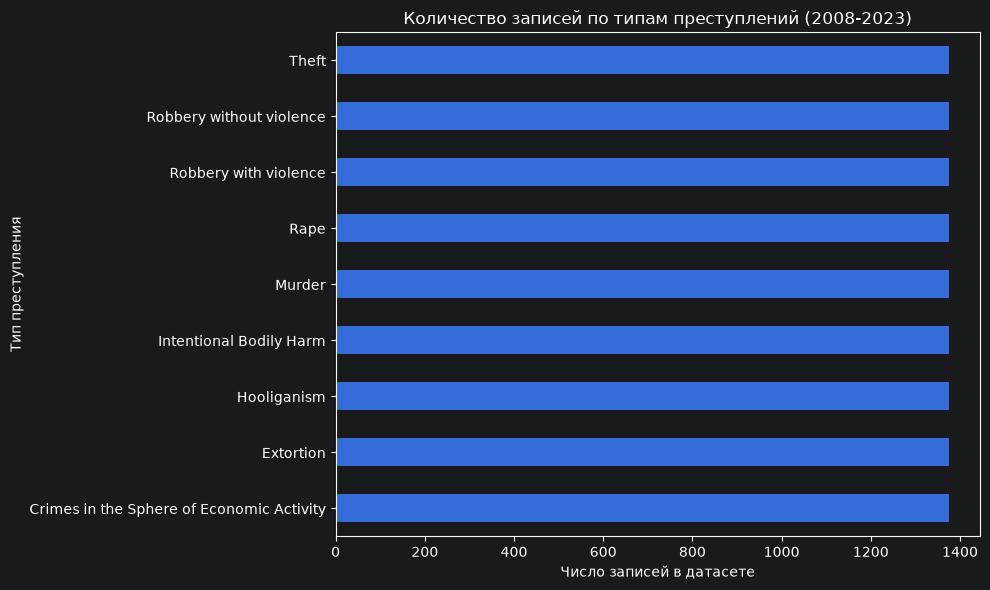

In [14]:
import matplotlib.pyplot as plt

counts = clean_df["Type of crime"].value_counts().sort_values()
ax = counts.plot(kind="barh", figsize=(10, 6))
ax.set_title("Количество записей по типам преступлений (2008-2023)")
ax.set_xlabel("Число записей в датасете")
ax.set_ylabel("Тип преступления")
plt.tight_layout()
plt.show()

9.2. Histogram: распределение температуры

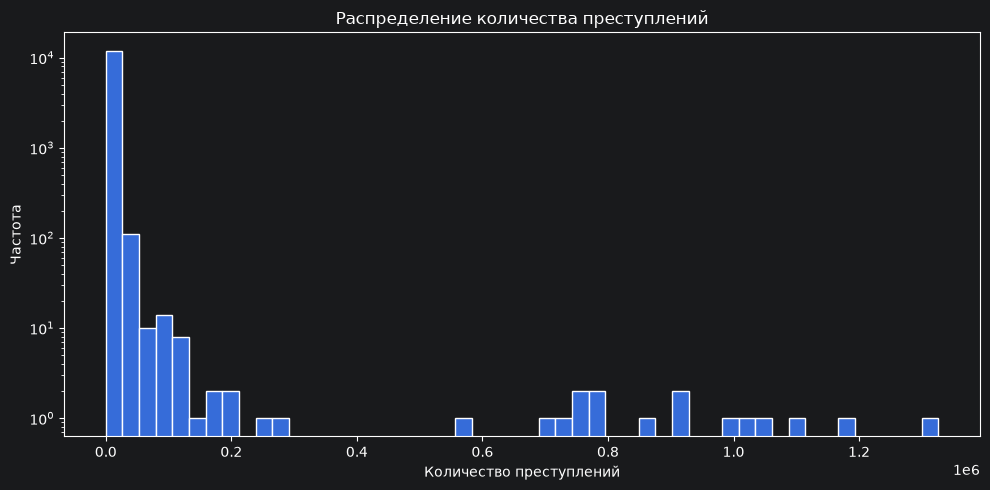

In [16]:
plt.figure(figsize=(10, 5))

all_crimes = clean_df["The number of crimes"].dropna()
plt.hist(all_crimes, bins=50, edgecolor="white", log=True)
plt.title("Распределение количества преступлений")
plt.xlabel("Количество преступлений")
plt.ylabel("Частота")
plt.tight_layout()
plt.show()

9.3 Line plot: Динамика убийств в РФ

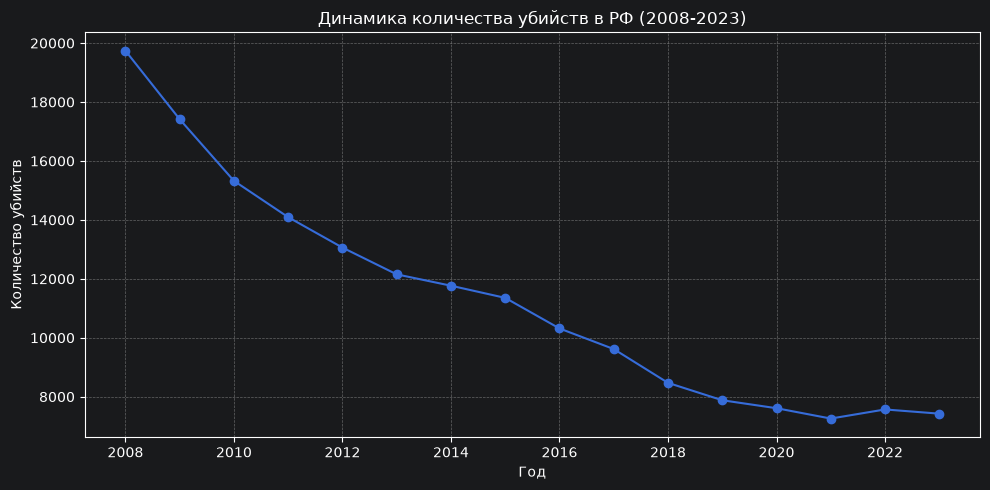

In [17]:
murder_russia = clean_df.loc[
    (clean_df["Type of crime"] == "Murder") &
    (clean_df["Region"] == "Russian Federation")
].sort_values("Year")

plt.figure(figsize=(10, 5))
plt.plot(
    murder_russia["Year"],
    murder_russia["The number of crimes"],
    marker='o'
)
plt.title("Динамика количества убийств в РФ (2008-2023)")
plt.xlabel("Год")
plt.ylabel("Количество убийств")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

9.4. Scatter plot: Сравнение Краж и Убийств по регионам в 2023 году

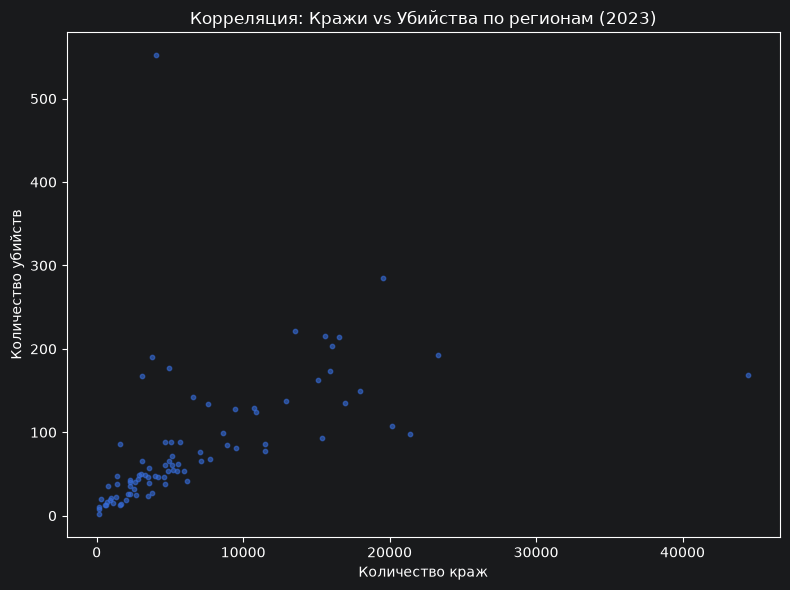

In [18]:
data_2023 = clean_df[
    (clean_df["Year"] == 2023) &
    (clean_df["Region"] != "Russian Federation")
]

pivot_2023 = data_2023.pivot_table(
    index="Region",
    columns="Type of crime",
    values="The number of crimes"
).reset_index()

if "Murder" in pivot_2023.columns and "Theft" in pivot_2023.columns:
    sample = pivot_2023.dropna(subset=["Murder", "Theft"])

    plt.figure(figsize=(8, 6))
    plt.scatter(
        sample["Theft"],
        sample["Murder"],
        s=10,
        alpha=0.6
    )
    plt.title("Корреляция: Кражи vs Убийства по регионам (2023)")
    plt.xlabel("Количество краж")
    plt.ylabel("Количество убийств")
    plt.tight_layout()
    plt.show()
else:
    print("Недостаточно данных для построения графика (проверьте названия типов преступлений)")

1 Динамика: Наблюдается четкий долгосрочный тренд на снижение общего уровня преступности в России с 2008 по 2023 год. Особенно заметно снижение краж и грабежей.

2 География: Пространственное распределение показывает концентрацию преступлений в Европейской части России, что коррелирует с плотностью населения.

10.1. Сохранение подготовленного DataFrame

In [22]:
from pathlib import Path
OUT = Path("output")
OUT.mkdir(exist_ok=True)

clean_df.to_csv(
    OUT / "CrimesRu_clean.csv",
    index=False,
    encoding="utf-8"
)
clean_df.to_json(
    OUT / "CrimesRu_clean.json",
    orient="records",
    lines=True,
    force_ascii=False
)
clean_df.to_parquet(
    OUT / "CrimesRu_clean.parquet",
    index=False,
    engine="pyarrow",
    compression="snappy"
)

10.2. Проверка round-trip

In [23]:
csv_back = pd.read_csv(OUT / "CrimesRu_clean.csv")
parquet_back = pd.read_parquet(OUT / "CrimesRu_clean.parquet")

print("CSV shape:", csv_back.shape)
print("Parquet shape:", parquet_back.shape)
print("\nParquet dtypes:")
print(parquet_back.dtypes)

CSV shape: (12384, 6)
Parquet shape: (12384, 6)

Parquet dtypes:
Type of crime                                          category
Region                                                 category
Year                                                      int16
The number of crimes                                    float64
The number of crimes (cases per 100.000 population)     float64
is_federal_level                                           bool
dtype: object


Очищенный и оптимизированный датасет успешно сохранен в форматах CSV, JSON и Parquet. Проверка целостности данных (round-trip) прошла успешно, типы данных сохранены.

# Общий вывод по работе
В ходе анализа статистики МВД РФ за период 2008–2023 годов подтверждена тенденция к оздоровлению криминогенной обстановки: общее количество регистрируемых преступлений стабильно снижается.

Структура преступности остается традиционной: доминируют имущественные преступления (кражи), тогда как доля насильственных преступлений относительно невелика. Географически картина преступности зеркально отражает демографическую карту страны.

Технически данные были успешно очищены от пропусков, оптимизированы по памяти и подготовлены для дальнейшего глубокого анализа.
